In [12]:
# Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, auc)
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [13]:
# Load data and create scenario groups
DATA_PATH = r'C:\Users\manur\OneDrive\Documents\Multi_Crop_Ranking_\Multi_Crop_Ranking\Notebooks\Models\Crop_training_data_FULL_F1.csv'
df = pd.read_csv(DATA_PATH)

ENV_COLS = [
    'temperature', 'rainfall', 'sunshine_hours',
    'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'
]

rounded = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded, index=False).astype('int64')

In [14]:
# Prepare features and target
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0}).astype(int)
DROP_COLS = ['suitability_class', 'suitability', 'texture', 'rooting_depth_m']
X = df.drop(columns=DROP_COLS)
groups = df['scenario_id']

categorical_cols = ['crop']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

In [15]:
# Train/test split by scenario
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train scenarios: {g_train.nunique()}, Test scenarios: {g_test.nunique()}')

Train: (1680, 11), Test: (420, 11)
Train scenarios: 1680, Test scenarios: 420


In [16]:
# Define preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

In [17]:
# Baseline SVM
baseline_pipe = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', SVC(probability=True, random_state=42))
])

baseline_pipe.fit(X_train, y_train)

baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

baseline_roc = roc_auc_score(y_test, baseline_proba)
baseline_pr = average_precision_score(y_test, baseline_proba)

print("=== Baseline SVM ===")
print(f"ROC-AUC: {baseline_roc:.4f}")
print(f"PR-AUC:  {baseline_pr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, baseline_pred, digits=3))

=== Baseline SVM ===
ROC-AUC: 0.9324
PR-AUC:  0.9572

Classification Report:
              precision    recall  f1-score   support

           0      0.830     0.759     0.793       174
           1      0.839     0.890     0.864       246

    accuracy                          0.836       420
   macro avg      0.835     0.824     0.828       420
weighted avg      0.835     0.836     0.834       420



In [18]:
# Expanded hyperparameter tuning with GridSearchCV
pipe = Pipeline(steps=[('preprocess', preprocessor),
                       ('model', SVC(probability=True, random_state=42))])

# Expanded parameter grid
param_grid = [
    {'model__kernel': ['rbf'], 'model__C': [0.1, 1, 10, 100],
     'model__gamma': ['scale', 'auto', 0.01, 0.1]},
    {'model__kernel': ['poly'], 'model__C': [0.1, 1, 10],
     'model__gamma': ['scale', 'auto'], 'model__degree': [2, 3, 4]},
    {'model__kernel': ['sigmoid'], 'model__C': [0.1, 1, 10],
     'model__gamma': ['scale', 'auto']}
]

cv = GroupKFold(n_splits=5)
gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train, groups=g_train)

print("\nBest parameters found:")
print(gs.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters found:
{'model__C': 100, 'model__gamma': 0.01, 'model__kernel': 'rbf'}


In [19]:
# Evaluate tuned model on test set
best_model = gs.best_estimator_
tuned_proba = best_model.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_proba >= 0.5).astype(int)

tuned_roc = roc_auc_score(y_test, tuned_proba)
tuned_pr = average_precision_score(y_test, tuned_proba)

print("=== Tuned SVM ===")
print("Test ROC-AUC:", tuned_roc)
print("Test PR-AUC:", tuned_pr)
print("Confusion Matrix:\n", confusion_matrix(y_test, tuned_pred))
print("Classification Report:\n", classification_report(y_test, tuned_pred, digits=3))


=== Tuned SVM ===
Test ROC-AUC: 0.9443276329315017
Test PR-AUC: 0.9639485258983445
Confusion Matrix:
 [[144  30]
 [ 26 220]]
Classification Report:
               precision    recall  f1-score   support

           0      0.847     0.828     0.837       174
           1      0.880     0.894     0.887       246

    accuracy                          0.867       420
   macro avg      0.864     0.861     0.862       420
weighted avg      0.866     0.867     0.866       420



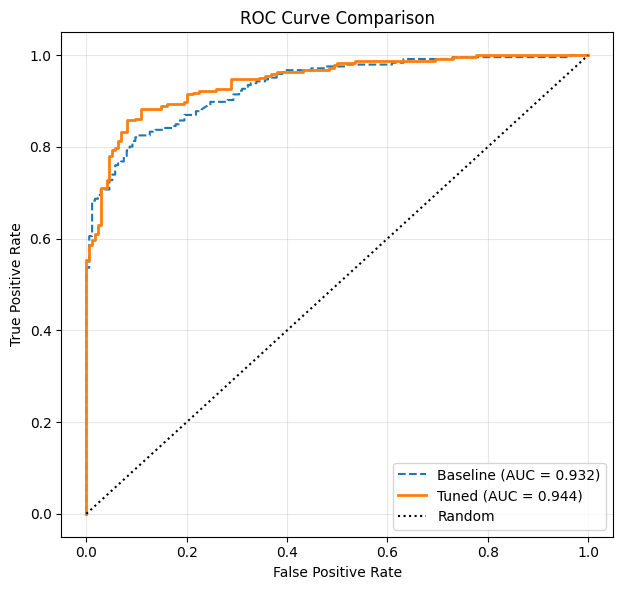

In [20]:
# Comparison plots (Baseline vs Tuned)
# ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {baseline_roc:.3f})', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {tuned_roc:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

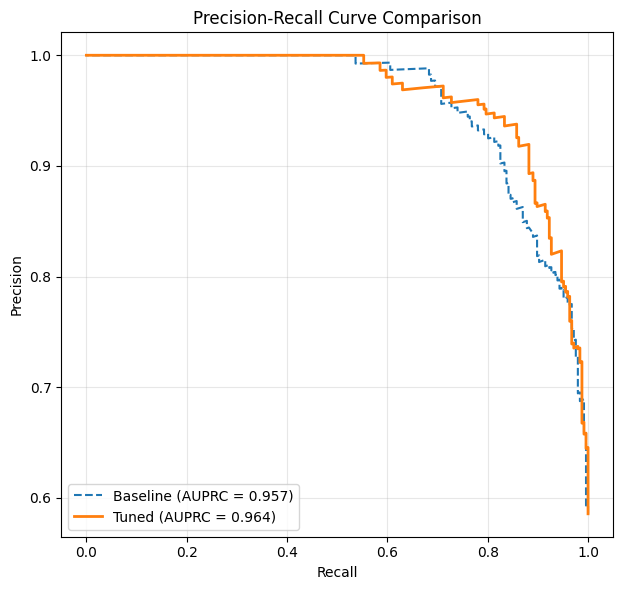

In [21]:
# PR curves
prec_base, rec_base, _ = precision_recall_curve(y_test, baseline_proba)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, tuned_proba)
pr_auc_base = auc(rec_base, prec_base)
pr_auc_tuned = auc(rec_tuned, prec_tuned)

plt.figure(figsize=(12,6))

plt.subplot(1,2,2)
plt.plot(rec_base, prec_base, label=f'Baseline (AUPRC = {pr_auc_base:.3f})', linestyle='--')
plt.plot(rec_tuned, prec_tuned, label=f'Tuned (AUPRC = {pr_auc_tuned:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Save models
joblib.dump(baseline_pipe, 'baseline_svm.pkl')
joblib.dump(best_model, 'tuned_svm.pkl')

['tuned_svm.pkl']